# 3D Allen-Cahn Identification

This notebook extends the 2D Allen-Cahn workflow to 3D. It imports the 3D IMEX solver and adjoint/PINN modules, generates reference forward and inverse data, checks solver convergence and discrete-adjoint gradients, trains the adjoint reaction model and a 3D PINN baseline, warm-starts the adjoint with the PINN force, and compares the recovered terminal states and reaction functions.

## 1. Import Dependencies and Reuse Shared Utilities

Set the working directory to the 3D Allen-Cahn folder, reload the local modules, and fix seeds and plotting defaults.

In [1]:
import os
import time
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.set_default_dtype(torch.float64)
np.random.seed(42)
torch.manual_seed(42)

new_dir = '/users/zzhan536/myData/playing_center/adjoint_test/AllenCahn_3D_identification'
os.chdir(new_dir)
print('cwd:', os.getcwd())

import cfg as cfg_mod
import solver as solver_mod
import adjoint_operator as adjoint_mod
import PINN as pinn_mod

importlib.reload(cfg_mod)
importlib.reload(solver_mod)
importlib.reload(pinn_mod)
importlib.reload(adjoint_mod)

from cfg import AllenCahn3DConfig
from solver import (
    make_xyz_grid,
    initial_condition,
    reaction_true,
    solve_allen_cahn_imex,
    run_mesh_convergence,
    estimate_orders,
    rel_l2_error,
)
from adjoint_operator import (
    AllenCahnIMEXAdjointNN,
    get_init_phi,
    gradient_check,
    invert_force_adjoint,
    nn_force_forward,
    simulate_trajectory_with_phi,
)
from PINN import build_models, load_models, reaction_from_model, train_pinn

plt.rcParams.update({'figure.dpi': 140, 'font.size': 12, 'axes.grid': False, 'image.cmap': 'RdBu_r'})
print('Imports OK')

cwd: /oscar/data/gk/zzhan536/playing_center/adjoint_test/AllenCahn_3D_identification
Imports OK


## 2. Define the 3D Allen-Cahn Problem

We solve

$$
\partial_t u = \varepsilon^2 (u_{xx}+u_{yy}+u_{zz}) + R(u), \qquad R(u)=u-u^3,
$$

with zero-Neumann boundary conditions on all faces and a smooth initial condition $u_0(x,y,z)=\cos(\pi x)\cos(\pi y)\cos(\pi z)$.

In [2]:
cfg_forward = AllenCahn3DConfig()
xx, yy, zz = make_xyz_grid(cfg_forward)
u0 = initial_condition(xx, yy, zz)

print(f'Grid: {cfg_forward.Nx} x {cfg_forward.Ny} x {cfg_forward.Nz}')
print(f'dt={cfg_forward.dt:.3e}, T={cfg_forward.t_final:.3f}, eps={cfg_forward.eps:.3e}')
print(f'u0 range = [{u0.min():.3f}, {u0.max():.3f}]')

Grid: 129 x 129 x 129
dt=5.000e-02, T=3.000, eps=1.000e-02
u0 range = [-1.000, 1.000]


## 3. Prepare IMEX Diagnostics

Define helper routines for mass, free energy, and slice extraction that will be used to inspect the imported IMEX forward solver.

In [3]:
def compute_mass(u, hx, hy, hz):
    return hx * hy * hz * np.sum(u)


def compute_free_energy(u, cfg):
    hx = cfg.Lx / (cfg.Nx - 1)
    hy = cfg.Ly / (cfg.Ny - 1)
    hz = cfg.Lz / (cfg.Nz - 1)
    ux = np.zeros_like(u)
    uy = np.zeros_like(u)
    uz = np.zeros_like(u)
    ux[1:-1, :, :] = (u[2:, :, :] - u[:-2, :, :]) / (2.0 * hx)
    uy[:, 1:-1, :] = (u[:, 2:, :] - u[:, :-2, :]) / (2.0 * hy)
    uz[:, :, 1:-1] = (u[:, :, 2:] - u[:, :, :-2]) / (2.0 * hz)
    bulk = 0.25 * (u**2 - 1.0) ** 2
    energy_density = 0.5 * cfg.eps**2 * (ux**2 + uy**2 + uz**2) + bulk
    return hx * hy * hz * np.sum(energy_density)


def midplane(field):
    return field[:, :, field.shape[2] // 3]


hx = cfg_forward.Lx / (cfg_forward.Nx - 1)
hy = cfg_forward.Ly / (cfg_forward.Ny - 1)
hz = cfg_forward.Lz / (cfg_forward.Nz - 1)
print('Diagnostic helpers ready')

Diagnostic helpers ready


## 4. Run the Forward Simulation

Generate a reference 3D trajectory with the IMEX solver and record basic diagnostics such as mass and free energy.

In [4]:
t0 = time.perf_counter()
u_hist, t_hist, _ = solve_allen_cahn_imex(cfg_forward, u0)
forward_runtime = time.perf_counter() - t0

masses = np.array([compute_mass(u, hx, hy, hz) for u in u_hist])
energies = np.array([compute_free_energy(u, cfg_forward) for u in u_hist])

print(f'Forward runtime: {forward_runtime:.3f} s')
print(f'Forward final simulated time: {t_hist[-1]:.3f}')
print(f'Trajectory shape: {u_hist.shape}')
print(f'Final state range: [{u_hist[-1].min():.3f}, {u_hist[-1].max():.3f}]')
print(f'Mass drift: {masses[-1] - masses[0]:.3e}')
print(f'Energy drop: {energies[0] - energies[-1]:.3e}')

Forward runtime: 12.579 s
Forward final simulated time: 3.000
Trajectory shape: (61, 129, 129, 129)
Final state range: [-1.000, 1.000]
Mass drift: 7.877e-20
Energy drop: 1.521e-01


## 5. Plot 3D Solution Slices and Diagnostics

Plot mid-plane slices of the state together with the mass and free-energy histories.

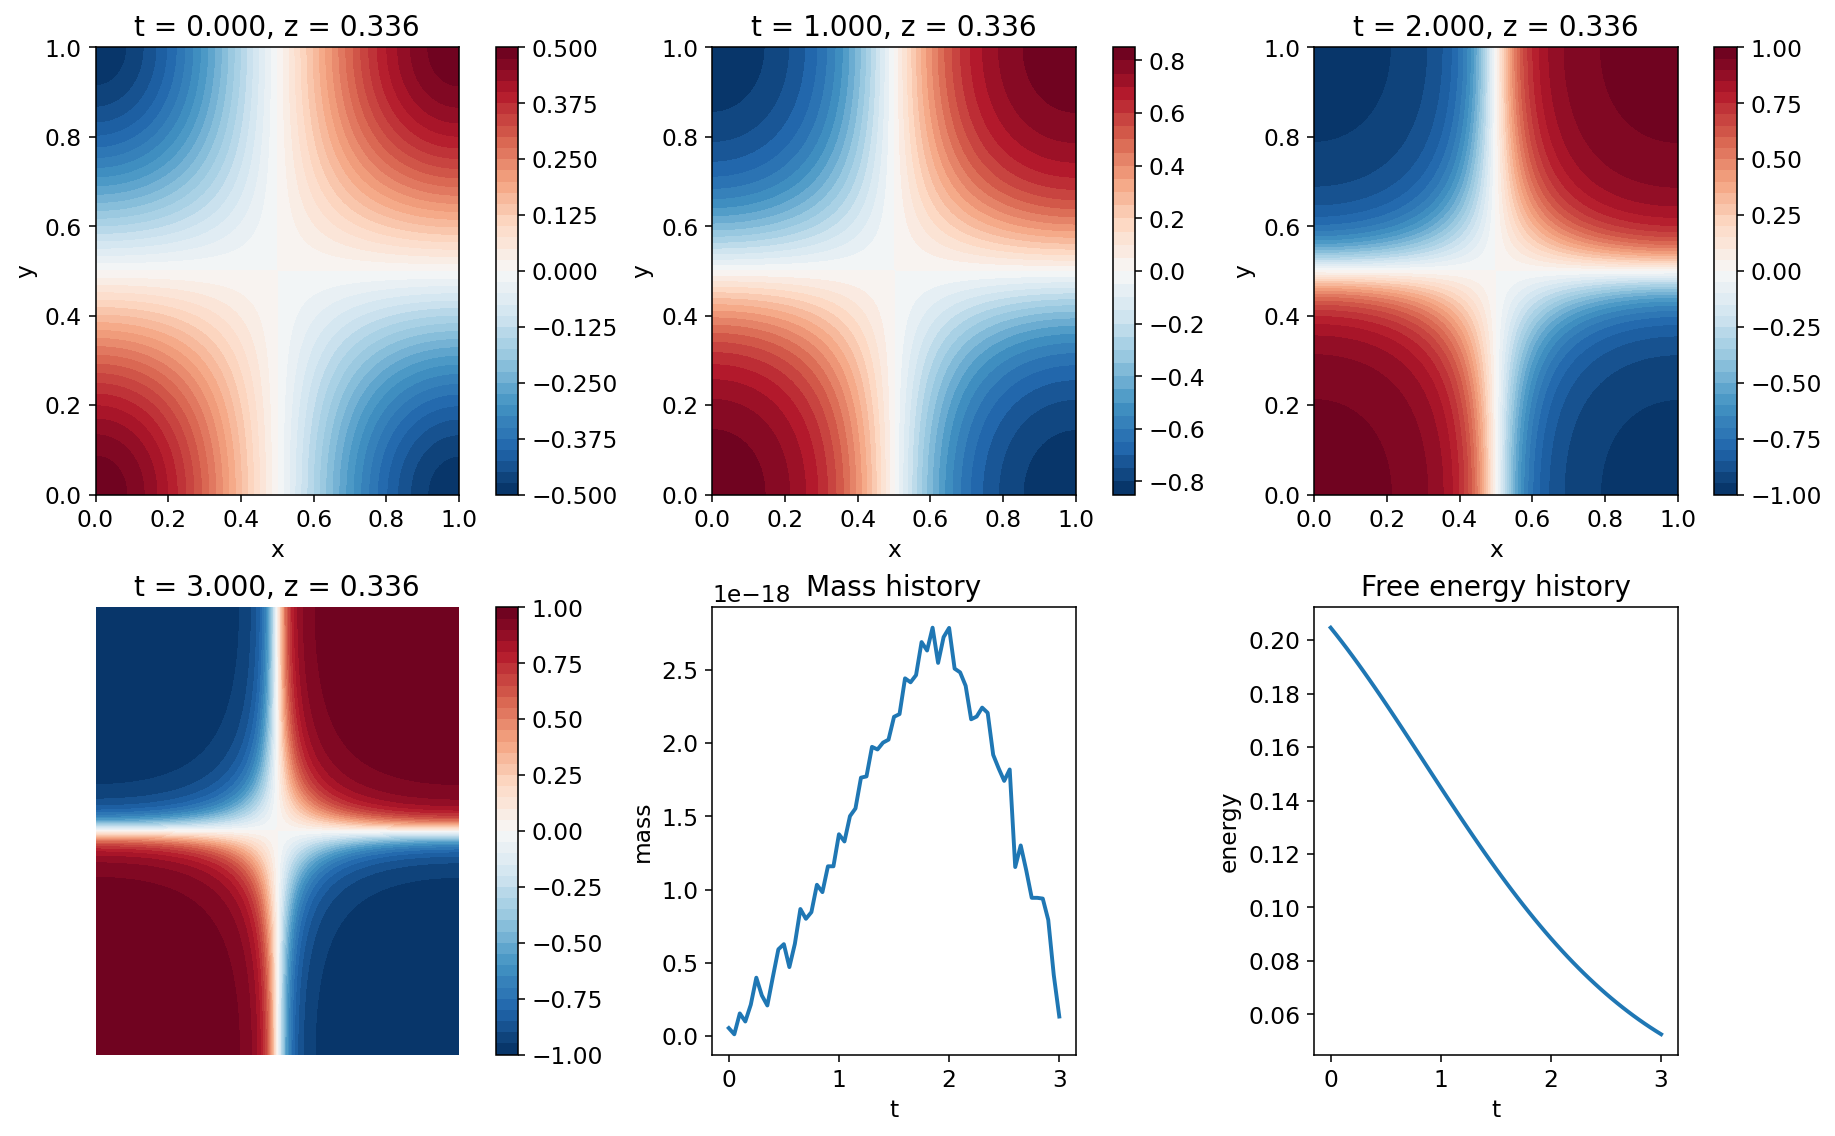

In [5]:
snap_ids = [0, len(t_hist) // 3, 2 * len(t_hist) // 3, len(t_hist) - 1]
z_mid = zz[:, :, zz.shape[2] // 3]
fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
for ax, idx in zip(axes.flat[:4], snap_ids):
    im = ax.contourf(xx[:, :, xx.shape[2] // 3], yy[:, :, yy.shape[2] // 3], midplane(u_hist[idx]), levels=40)
    plt.colorbar(im, ax=ax)
    ax.set_title(f't = {t_hist[idx]:.3f}, z = {z_mid[0,0]:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axes[1, 1].plot(t_hist, masses, lw=2)
axes[1, 1].set_title('Mass history')
axes[1, 1].set_xlabel('t')
axes[1, 1].set_ylabel('mass')

axes[1, 2].plot(t_hist, energies, lw=2)
axes[1, 2].set_title('Free energy history')
axes[1, 2].set_xlabel('t')
axes[1, 2].set_ylabel('energy')

axes[1, 0].axis('off')
plt.show()

## 6. Check Spatial and Temporal Convergence

Run separate spatial and temporal refinement studies for the 3D IMEX solver.

Spatial convergence (fixed dt)
N    h          dt         relL2       relLinf
17  6.250e-02  1.221e-04  7.084e-07  5.292e-07
33  3.125e-02  1.221e-04  1.444e-07  1.061e-07

Observed spatial orders from relL2:
  h=6.250e-02 -> 3.125e-02: p ~ 2.29

Temporal convergence (fixed grid)
N    h          dt         relL2       relLinf
33  3.125e-02  4.000e-02  3.765e-04  2.750e-04
33  3.125e-02  2.000e-02  1.006e-04  7.133e-05
33  3.125e-02  1.000e-02  2.048e-05  1.433e-05

Observed temporal orders from relL2:
  dt=4.000e-02 -> 2.000e-02: p ~ 1.90
  dt=2.000e-02 -> 1.000e-02: p ~ 2.30


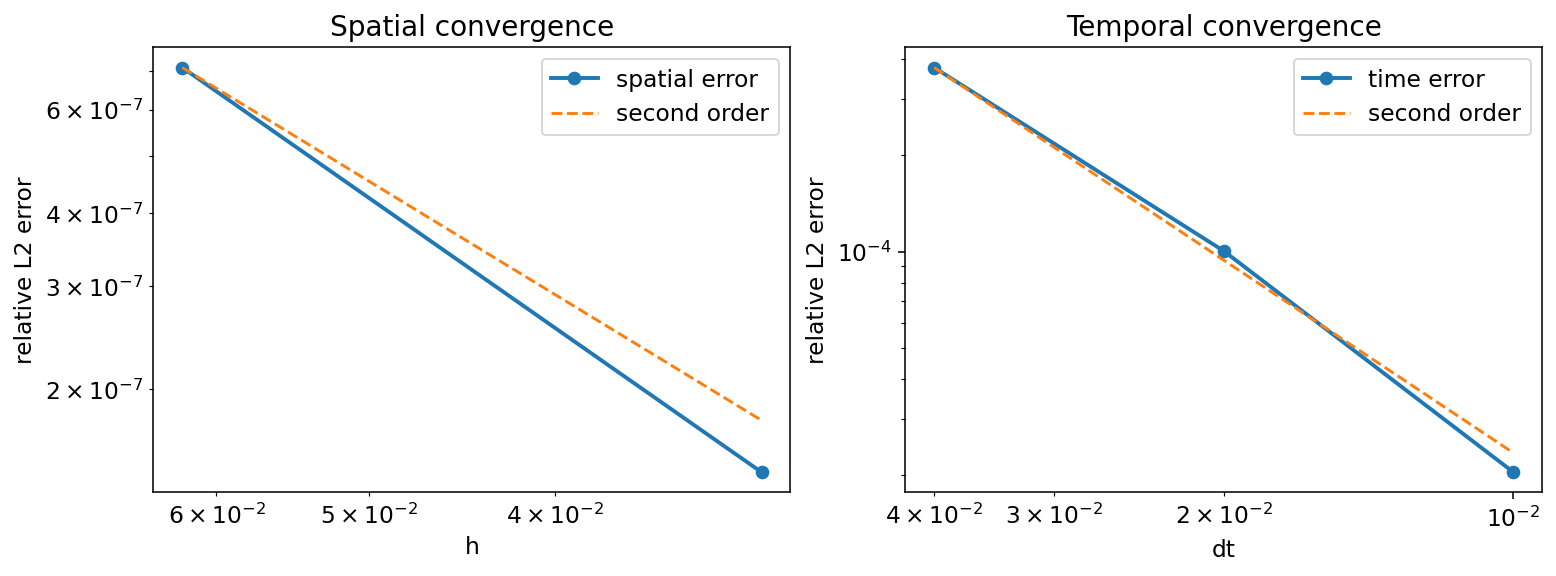

In [6]:
t_final_conv = 0.08
eps_conv = cfg_forward.eps


def run_forward_case(n_pts, dt, t_final, eps):
    cfg_case = AllenCahn3DConfig(
        Nx=n_pts,
        Ny=n_pts,
        Nz=n_pts,
        dt=dt,
        t_final=t_final,
        eps=eps,
    )
    xx_case, yy_case, zz_case = make_xyz_grid(cfg_case)
    u0_case = initial_condition(xx_case, yy_case, zz_case)
    u_hist_case, _, _ = solve_allen_cahn_imex(cfg_case, u0_case)
    return u_hist_case[-1]


def estimate_refinement_orders(rows, abscissa_idx):
    orders = []
    for idx in range(len(rows) - 1):
        v1 = rows[idx][abscissa_idx]
        v2 = rows[idx + 1][abscissa_idx]
        e1 = rows[idx][3]
        e2 = rows[idx + 1][3]
        if e1 > 0.0 and e2 > 0.0 and v1 != v2:
            orders.append((v1, v2, np.log(e1 / e2) / np.log(v1 / v2)))
    return orders


spatial_sizes = [17, 33, 65]
h_fine = 1.0 / (spatial_sizes[-1] - 1)
dt_spatial = 0.5 * h_fine**2
u_ref_space = run_forward_case(spatial_sizes[-1], dt_spatial, t_final_conv, eps_conv)
spatial_results = []
for n_pts in spatial_sizes[:-1]:
    u_num = run_forward_case(n_pts, dt_spatial, t_final_conv, eps_conv)
    ratio = (spatial_sizes[-1] - 1) // (n_pts - 1)
    u_ref_coarse = u_ref_space[::ratio, ::ratio, ::ratio]
    err = u_num - u_ref_coarse
    h = 1.0 / (n_pts - 1)
    rel_l2 = np.linalg.norm(err.ravel()) / max(np.linalg.norm(u_ref_coarse.ravel()), 1.0e-30)
    rel_linf = np.max(np.abs(err)) / max(np.max(np.abs(u_ref_coarse)), 1.0e-30)
    spatial_results.append((n_pts, h, dt_spatial, rel_l2, rel_linf))

spatial_orders = estimate_refinement_orders(spatial_results, abscissa_idx=1)

time_n = 33
time_h = 1.0 / (time_n - 1)
time_dts = [4.0e-2, 2.0e-2, 1.0e-2, 5.0e-3]
u_ref_time = run_forward_case(time_n, time_dts[-1], t_final_conv, eps_conv)
time_results = []
for dt in time_dts[:-1]:
    u_num = run_forward_case(time_n, dt, t_final_conv, eps_conv)
    err = u_num - u_ref_time
    rel_l2 = np.linalg.norm(err.ravel()) / max(np.linalg.norm(u_ref_time.ravel()), 1.0e-30)
    rel_linf = np.max(np.abs(err)) / max(np.max(np.abs(u_ref_time)), 1.0e-30)
    time_results.append((time_n, time_h, dt, rel_l2, rel_linf))

time_orders = estimate_refinement_orders(time_results, abscissa_idx=2)

print('Spatial convergence (fixed dt)')
print('N    h          dt         relL2       relLinf')
for row in spatial_results:
    n, h, dt, rel_l2, rel_linf = row
    print(f'{n:2d}  {h:9.3e}  {dt:9.3e}  {rel_l2:9.3e}  {rel_linf:9.3e}')

print('\nObserved spatial orders from relL2:')
for h1, h2, order in spatial_orders:
    print(f'  h={h1:.3e} -> {h2:.3e}: p ~ {order:.2f}')

print('\nTemporal convergence (fixed grid)')
print('N    h          dt         relL2       relLinf')
for row in time_results:
    n, h, dt, rel_l2, rel_linf = row
    print(f'{n:2d}  {h:9.3e}  {dt:9.3e}  {rel_l2:9.3e}  {rel_linf:9.3e}')

print('\nObserved temporal orders from relL2:')
for dt1, dt2, order in time_orders:
    print(f'  dt={dt1:.3e} -> {dt2:.3e}: p ~ {order:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

hs = np.array([row[1] for row in spatial_results])
spatial_errs = np.array([row[3] for row in spatial_results])
axes[0].loglog(hs, spatial_errs, 'o-', lw=2, label='spatial error')
axes[0].loglog(hs, spatial_errs[0] * (hs / hs[0])**2, '--', label='second order')
axes[0].invert_xaxis()
axes[0].set_xlabel('h')
axes[0].set_ylabel('relative L2 error')
axes[0].set_title('Spatial convergence')
axes[0].legend()

dts = np.array([row[2] for row in time_results])
time_errs = np.array([row[3] for row in time_results])
axes[1].loglog(dts, time_errs, 'o-', lw=2, label='time error')
axes[1].loglog(dts, time_errs[0] * (dts / dts[0])**2, '--', label='second order')
axes[1].invert_xaxis()
axes[1].set_xlabel('dt')
axes[1].set_ylabel('relative L2 error')
axes[1].set_title('Temporal convergence')
axes[1].legend()

plt.show()

In [ ]:
if False:
    from scipy.interpolate import RegularGridInterpolator

    selection_t_final = 3
    selection_eps = cfg_forward.eps

    # Each setup is [dt, dx].
    setup_a = [0.05, 1.0 / 128]
    setup_b = [0.025, 1.0 / 256]
    """  
    Setup comparison
    setup A: dt=5.000e-02, dx=7.812e-03, cells=128
    setup B: dt=2.500e-02, dx=3.906e-03, cells=256
    comparison: coarser setup vs finer-dx setup projected to the coarse grid
    relative L2 error = 4.398062e-04
    """


    def run_resolution_case(dt, dx, t_final, eps):
        dt = float(dt)
        dx = float(dx)
        n_cells = int(round(cfg_forward.Lx / dx))
        if not np.isclose(n_cells * dx, cfg_forward.Lx, rtol=0.0, atol=1.0e-12):
            raise ValueError('dx must divide the domain length exactly.')

        n_pts = n_cells + 1
        cfg_case = AllenCahn3DConfig(
            Nx=n_pts,
            Ny=n_pts,
            Nz=n_pts,
            dt=dt,
            t_final=t_final,
            eps=eps,
        )
        xx_case, yy_case, zz_case = make_xyz_grid(cfg_case)
        u0_case = initial_condition(xx_case, yy_case, zz_case)
        u_hist_case, t_hist_case, _ = solve_allen_cahn_imex(cfg_case, u0_case)
        return {
            'n_cells': n_cells,
            'n_pts': n_pts,
            'dx': cfg_forward.Lx / n_cells,
            'dt': dt,
            't_final': t_hist_case[-1],
            'grid': (xx_case[:, 0, 0], yy_case[0, :, 0], zz_case[0, 0, :]),
            'uT': u_hist_case[-1],
        }


    def compare_setups(setup_a, setup_b, t_final, eps):
        if len(setup_a) != 2 or len(setup_b) != 2:
            raise ValueError('Each setup must be a two-entry list [dt, dx].')

        case_a = run_resolution_case(setup_a[0], setup_a[1], t_final, eps)
        case_b = run_resolution_case(setup_b[0], setup_b[1], t_final, eps)

        if case_a['n_pts'] == case_b['n_pts'] and np.isclose(case_a['dx'], case_b['dx']):
            rel_err = rel_l2_error(case_a['uT'], case_b['uT'])
            reference_label = 'direct same-grid comparison'
        else:
            coarse_case, fine_case = sorted([case_a, case_b], key=lambda case: case['dx'], reverse=True)
            fine_interp = RegularGridInterpolator(
                fine_case['grid'],
                fine_case['uT'],
                method='linear',
                bounds_error=False,
                fill_value=None,
            )
            xc, yc, zc = coarse_case['grid']
            XXc, YYc, ZZc = np.meshgrid(xc, yc, zc, indexing='ij')
            pts = np.column_stack((XXc.ravel(), YYc.ravel(), ZZc.ravel()))
            u_fine_on_coarse = fine_interp(pts).reshape(
                coarse_case['n_pts'],
                coarse_case['n_pts'],
                coarse_case['n_pts'],
            )
            rel_err = rel_l2_error(coarse_case['uT'], u_fine_on_coarse)
            reference_label = 'coarser setup vs finer-dx setup projected to the coarse grid'

        print('Setup comparison')
        print(f'  setup A: dt={case_a["dt"]:.3e}, dx={case_a["dx"]:.3e}, cells={case_a["n_cells"]}')
        print(f'  setup B: dt={case_b["dt"]:.3e}, dx={case_b["dx"]:.3e}, cells={case_b["n_cells"]}')
        print(f'  comparison: {reference_label}')
        print(f'  relative L2 error = {rel_err:.6e}')

        return {
            'setup_a': case_a,
            'setup_b': case_b,
            'comparison': reference_label,
            'rel_l2_error': rel_err,
        }


    resolution_comparison = compare_setups(
        setup_a,
        setup_b,
        selection_t_final,
        selection_eps,
        )

## 7. Generate the Inverse Target Data

Use solver-generated terminal data as the inverse target for the terminal-state mismatch objective solved below.

In [5]:
cfg_inv = AllenCahn3DConfig()

xx_inv, yy_inv, zz_inv = make_xyz_grid(cfg_inv)
u0_inv = initial_condition(xx_inv, yy_inv, zz_inv)

t0 = time.perf_counter()
u_ref_hist, t_ref_hist, _ = solve_allen_cahn_imex(cfg_inv, u0_inv)
target_runtime = time.perf_counter() - t0
uT_target = u_ref_hist[-1]

print(f'Inverse grid: {cfg_inv.Nx} x {cfg_inv.Ny} x {cfg_inv.Nz}, T={cfg_inv.t_final}, dt={cfg_inv.dt}')
print(f'Target generation runtime: {target_runtime:.3f} s')
print(f'Target generation final simulated time: {t_ref_hist[-1]:.3f}')
print(f'Target terminal norm = {np.linalg.norm(uT_target):.6e}')

Inverse grid: 129 x 129 x 129, T=3.0, dt=0.05
Target generation runtime: 12.497 s
Target generation final simulated time: 3.000
Target terminal norm = 1.252384e+03


## 8. Initialize the Discrete Adjoint Solver

Instantiate `AllenCahnIMEXAdjointNN` on the inverse grid and inspect the initial loss, gradient norm, and parameter count.

In [13]:
adj = AllenCahnIMEXAdjointNN(cfg_inv)
phi0 = get_init_phi(cfg_inv)
loss0, grad0 = adj.scipy_objective(phi0, u0_inv, uT_target)

print(f'Initial adjoint loss = {loss0:.6e}')
print(f'Initial gradient norm = {np.linalg.norm(grad0):.6e}')
print(f'Number of reaction parameters = {phi0.size}')

Initial adjoint loss = 1.685405e-01
Initial gradient norm = 9.351224e-01
Number of reaction parameters = 1153


## 9. Verify Gradients and Run Adjoint Identification

Compare adjoint derivatives with centered finite differences, run a Taylor test, and then optimize the reaction model with the discrete adjoint.

loss(phi0)     = 1.685405e-01
||grad(phi0)|| = 9.351224e-01
max rel err    = 1.235e-04
median rel err = 1.169e-04
dir= 0  adj=-3.119311e-02  fd=-3.118926e-02  rel=1.235e-04
dir= 1  adj=3.880769e-03  fd=3.880377e-03  rel=1.011e-04
dir= 2  adj=-2.834054e-02  fd=-2.833719e-02  rel=1.181e-04
dir= 3  adj=3.036154e-02  fd=3.035803e-02  rel=1.157e-04


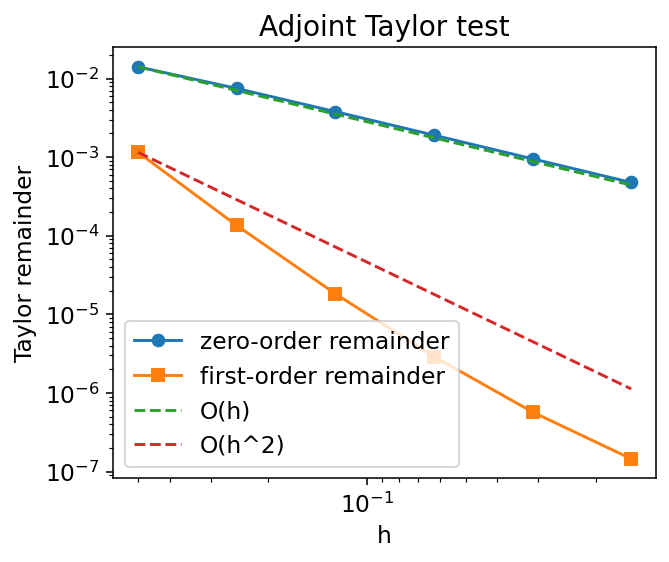

In [14]:
grad_report = gradient_check(cfg_inv, u0_inv, uT_target, phi0, n_dirs=4, eps_fd=1.0e-6)
print(f"loss(phi0)     = {grad_report['loss']:.6e}")
print(f"||grad(phi0)|| = {grad_report['grad_norm']:.6e}")
print(f"max rel err    = {grad_report['max_rel_err']:.3e}")
print(f"median rel err = {grad_report['median_rel_err']:.3e}")
for row in grad_report['rows']:
    print(f"dir={row['dir']:2d}  adj={row['adj']:.6e}  fd={row['fd']:.6e}  rel={row['rel_err']:.3e}")

rng = np.random.default_rng(7)
direction = rng.standard_normal(phi0.shape)
direction /= np.linalg.norm(direction)
steps = 0.5 ** np.arange(1, 7)
base_loss, base_grad = adj.scipy_objective(phi0, u0_inv, uT_target)
err0 = []
err1 = []
for h in steps:
    pert_loss, _ = adj.scipy_objective(phi0 + h * direction, u0_inv, uT_target)
    err0.append(abs(pert_loss - base_loss))
    err1.append(abs(pert_loss - base_loss - h * np.dot(base_grad, direction)))

plt.figure(figsize=(5, 4))
plt.loglog(steps, err0, 'o-', label='zero-order remainder')
plt.loglog(steps, err1, 's-', label='first-order remainder')
plt.loglog(steps, err0[0] * (steps / steps[0]), '--', label='O(h)')
plt.loglog(steps, err1[0] * (steps / steps[0])**2, '--', label='O(h^2)')
plt.gca().invert_xaxis()
plt.xlabel('h')
plt.ylabel('Taylor remainder')
plt.title('Adjoint Taylor test')
plt.legend()
plt.show()

In [15]:
phi_adj, hist_adj = invert_force_adjoint(u0_inv, uT_target, cfg_inv, phi0, n_steps_warmup=20)
u_hist_adj, t_hist_adj = simulate_trajectory_with_phi(cfg_inv, u0_inv, phi_adj)
uT_adj = u_hist_adj[-1]
print(f'Adjoint runtime: {hist_adj["runtime_sec"]:.3f} s')
print(f'Adjoint replay final simulated time: {t_hist_adj[-1]:.3f}')
print(f'Adjoint relL2 terminal error: {rel_l2_error(uT_adj, uT_target):.3e}')

[Adj][adam] step=0001 loss=1.685405e-01 |g|=9.351e-01 rel_uT=6.319e-01
[Adj][adam] step=0020 loss=1.131592e-01 |g|=1.530e-01 rel_uT=5.501e-01


/oscar/data/gk/zzhan536/playing_center/adjoint_test/AllenCahn_3D_identification/adjoint_operator.py:324: OptimizeWarning: Unknown solver options: maxfun
  result = minimize(


[Adj][bfgs] iter=0001 loss=1.127761e-01 |g|=1.280e-01 rel_uT=5.492e-01 rel_f=6.392e-01
[Adj][bfgs] iter=0020 loss=2.854391e-04 |g|=1.244e-01 rel_uT=2.763e-02 rel_f=1.658e-01
[Adj][bfgs] iter=0040 loss=2.985365e-05 |g|=1.768e-02 rel_uT=8.935e-03 rel_f=6.911e-02
[Adj][bfgs] iter=0060 loss=3.407939e-06 |g|=5.157e-03 rel_uT=3.019e-03 rel_f=4.373e-02
[Adj][bfgs] iter=0080 loss=7.045852e-07 |g|=1.999e-03 rel_uT=1.373e-03 rel_f=1.486e-02
[Adj][bfgs] iter=0100 loss=6.102315e-08 |g|=1.249e-03 rel_uT=4.040e-04 rel_f=4.274e-03
[Adj][bfgs] iter=0120 loss=2.088890e-08 |g|=1.155e-03 rel_uT=2.363e-04 rel_f=3.324e-03
[Adj][bfgs] iter=0140 loss=1.390202e-08 |g|=8.396e-04 rel_uT=1.928e-04 rel_f=2.904e-03
[Adj][bfgs] iter=0160 loss=5.219431e-09 |g|=3.920e-04 rel_uT=1.181e-04 rel_f=1.522e-03
[Adj][bfgs] iter=0180 loss=1.988506e-09 |g|=7.253e-05 rel_uT=7.292e-05 rel_f=9.786e-04
[Adj][bfgs] iter=0200 loss=7.982417e-10 |g|=6.003e-05 rel_uT=4.620e-05 rel_f=5.908e-04
[Adj][bfgs] done status=1 loss=7.982417e-10

## 10. Inspect the 3D PINN Baseline Setup

Summarize the PINN architecture and sampling configuration before training.

In [4]:
print(f'PINN state network width/depth: {cfg_inv.hidden_U}, {cfg_inv.layers_U}')
print(f'PINN reaction network width/depth: {cfg_inv.hidden_S}, {cfg_inv.layers_S}')
print(f'Interior collocation points per epoch: {cfg_inv.n_interior}')
print(f'Boundary samples per batch: {cfg_inv.n_bc_t}')
print(f'Observation samples per batch: {cfg_inv.n_data_t}')

PINN state network width/depth: 32, 3
PINN reaction network width/depth: 32, 2
Interior collocation points per epoch: 20000
Boundary samples per batch: 5000
Observation samples per batch: 80000


## 11. Train the PINN and Generate Predictions

Train the direct-residual PINN, evaluate its terminal-state prediction, and replay the learned reaction with the IMEX solver.

In [5]:
hist_pinn = train_pinn(u0_inv, uT_target, cfg_inv)
U_theta, S_phi = build_models(cfg_inv)
load_models(cfg_inv, U_theta, S_phi, cfg_inv.pinn_scipy_model)

with torch.no_grad():
    xyzt_T = torch.tensor(
        np.column_stack([
            xx_inv.reshape(-1),
            yy_inv.reshape(-1),
            zz_inv.reshape(-1),
            np.full(xx_inv.size, cfg_inv.t_final),
        ]),
        dtype=torch.float64,
        device=cfg_inv.device,
    )
    uT_pinn_direct = U_theta(xyzt_T).detach().cpu().numpy().reshape(cfg_inv.Nx, cfg_inv.Ny, cfg_inv.Nz)

u_hist_pinn_solver, t_hist_pinn_solver, _ = solve_allen_cahn_imex(
    cfg_inv,
    u0_inv,
    reaction_fun=lambda u: reaction_from_model(S_phi, u, cfg_inv.device),
)
uT_pinn_solver = u_hist_pinn_solver[-1]

print(f'PINN runtime: {hist_pinn["runtime_sec"]:.3f} s')
print(f'PINN replay final simulated time: {t_hist_pinn_solver[-1]:.3f}')
print(f'PINN direct relL2 terminal error: {rel_l2_error(uT_pinn_direct, uT_target):.3e}')
print(f'PINN solver relL2 terminal error: {rel_l2_error(uT_pinn_solver, uT_target):.3e}')

/users/zzhan536/miniconda3/envs/opt_2nd/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[PINN][adam] step=0001 loss=1.560747e+00 L_res=1.452e-01 L_ic=2.243e-01 L_bc=4.462e-02 L_data=1.147e+00 rel_uT=1.138e+00 rel_f=1.341e+00 lr=1.000e-03
[PINN][adam] step=0100 loss=8.577353e-01 L_res=1.223e-04 L_ic=1.275e-01 L_bc=6.928e-04 L_data=7.294e-01 rel_uT=9.999e-01 rel_f=9.273e-01 lr=3.000e-04
[PINN][adam] step=0200 loss=8.568292e-01 L_res=6.611e-05 L_ic=1.273e-01 L_bc=4.807e-04 L_data=7.290e-01 rel_uT=9.996e-01 rel_f=9.266e-01 lr=9.000e-05
[PINN][adam] step=0300 loss=8.565465e-01 L_res=5.569e-05 L_ic=1.272e-01 L_bc=4.377e-04 L_data=7.289e-01 rel_uT=9.996e-01 rel_f=9.265e-01 lr=2.700e-05
[PINN][adam] step=0400 loss=8.564493e-01 L_res=5.277e-05 L_ic=1.271e-01 L_bc=4.252e-04 L_data=7.289e-01 rel_uT=9.995e-01 rel_f=9.265e-01 lr=8.100e-06
[PINN][adam] step=0500 loss=8.564160e-01 L_res=5.184e-05 L_ic=1.271e-01 L_bc=4.212e-04 L_data=7.288e-01 rel_uT=9.995e-01 rel_f=9.265e-01 lr=2.430e-06
[PINN][bfgs] step=0001 loss=8.561304e-01 epoch=01 |g|=3.647e-02 L_res=4.272e-05 L_ic=1.270e-01 L_bc=

/oscar/data/gk/zzhan536/playing_center/adjoint_test/AllenCahn_3D_identification/PINN.py:191: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  blob = torch.load(path, map_locati

PINN runtime: 428.895 s
PINN replay final simulated time: 3.000
PINN direct relL2 terminal error: 1.479e-03
PINN solver relL2 terminal error: 5.464e-04


## 12. Restart the Adjoint from the PINN Force

Use the learned PINN reaction network as the initial guess for the adjoint reaction model, save the restarted history separately, and compare its convergence against the original adjoint run.

In [8]:
from dataclasses import replace
from torch.nn.utils import parameters_to_vector

adj_restart_path = 'history/ac3d_adj_nn_restart.npz'
adj_restart_model = 'history/ac3d_adj_nn_restart.pt'
cfg_adj_restart = replace(
    cfg_inv,
    adj_nn_path=adj_restart_path,
    adj_nn_model=adj_restart_model,
    scipy_adj_nn_maxiter=100,
 )

if 'S_phi' not in globals():
    if not os.path.exists(cfg_inv.pinn_scipy_model):
        raise FileNotFoundError(
            f'Missing PINN model file: {cfg_inv.pinn_scipy_model}. Run the PINN training cell first.'
        )
    U_theta_restart, S_phi_restart = build_models(cfg_inv)
    load_models(cfg_inv, U_theta_restart, S_phi_restart, cfg_inv.pinn_scipy_model)
else:
    S_phi_restart = S_phi

phi0_adj_restart = parameters_to_vector(list(S_phi_restart.parameters())).detach().cpu().numpy().astype(float)
phi_adj_restart, hist_adj_restart = invert_force_adjoint(
    u0_inv,
    uT_target,
    cfg_adj_restart,
    phi0_adj_restart,
    n_steps_warmup=0,
 )
u_hist_adj_restart, t_hist_adj_restart = simulate_trajectory_with_phi(cfg_adj_restart, u0_inv, phi_adj_restart)
uT_adj_restart = u_hist_adj_restart[-1]

u_probe_restart = np.linspace(-1.0, 1.0, 1001)
f_adj_restart, _, _ = nn_force_forward(u_probe_restart, phi_adj_restart, cfg_adj_restart)
f_true_restart = reaction_true(u_probe_restart)

print(f'Restarted adjoint maxiter: {cfg_adj_restart.scipy_adj_nn_maxiter}')
print(f'Restarted adjoint runtime: {hist_adj_restart["runtime_sec"]:.3f} s')
print(f'Restarted adjoint replay final simulated time: {t_hist_adj_restart[-1]:.3f}')
print(f'Restarted adjoint relL2 terminal error: {rel_l2_error(uT_adj_restart, uT_target):.3e}')
print(f'Restarted adjoint relL2 force error: {rel_l2_error(f_adj_restart, f_true_restart):.3e}')
print(f'Saved restarted adjoint history: {adj_restart_path}')

/oscar/data/gk/zzhan536/playing_center/adjoint_test/AllenCahn_3D_identification/PINN.py:191: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  blob = torch.load(path, map_locati

[Adj][bfgs] iter=0001 loss=1.053024e-07 |g|=5.269e-03 rel_uT=5.307e-04 rel_f=2.384e-03
[Adj][bfgs] iter=0020 loss=8.572474e-09 |g|=1.817e-03 rel_uT=1.514e-04 rel_f=1.961e-03
[Adj][bfgs] iter=0040 loss=4.215470e-09 |g|=6.650e-04 rel_uT=1.062e-04 rel_f=1.649e-03
[Adj][bfgs] iter=0060 loss=2.417473e-09 |g|=1.370e-04 rel_uT=8.040e-05 rel_f=1.154e-03
[Adj][bfgs] iter=0080 loss=1.470336e-09 |g|=2.509e-04 rel_uT=6.270e-05 rel_f=8.666e-04
[Adj][bfgs] iter=0100 loss=1.434596e-10 |g|=2.315e-04 rel_uT=1.959e-05 rel_f=2.880e-04
[Adj][bfgs] done status=1 loss=1.434596e-10 nfev=126
Restarted adjoint maxiter: 100
Restarted adjoint runtime: 2448.498 s
Restarted adjoint replay final simulated time: 3.000
Restarted adjoint relL2 terminal error: 1.959e-05
Restarted adjoint relL2 force error: 2.880e-04
Saved restarted adjoint history: history/ac3d_adj_nn_restart.npz


## 13. Compare Adjoint and PINN Results

Compare terminal-state accuracy, learned reaction functions, runtime, and training histories, including the restarted adjoint run when available.

Summary metrics
---------------
Adjoint terminal relL2 : 4.620e-05
PINN direct relL2     : 1.479e-03
PINN solver relL2     : 5.464e-04
Adjoint runtime [s]   : 5469.269
PINN runtime [s]      : 428.895
Adjoint params        : 1153
PINN params           : 3458
Adjoint Hessian proxy : 0.011 GB
PINN Hessian proxy    : 0.096 GB


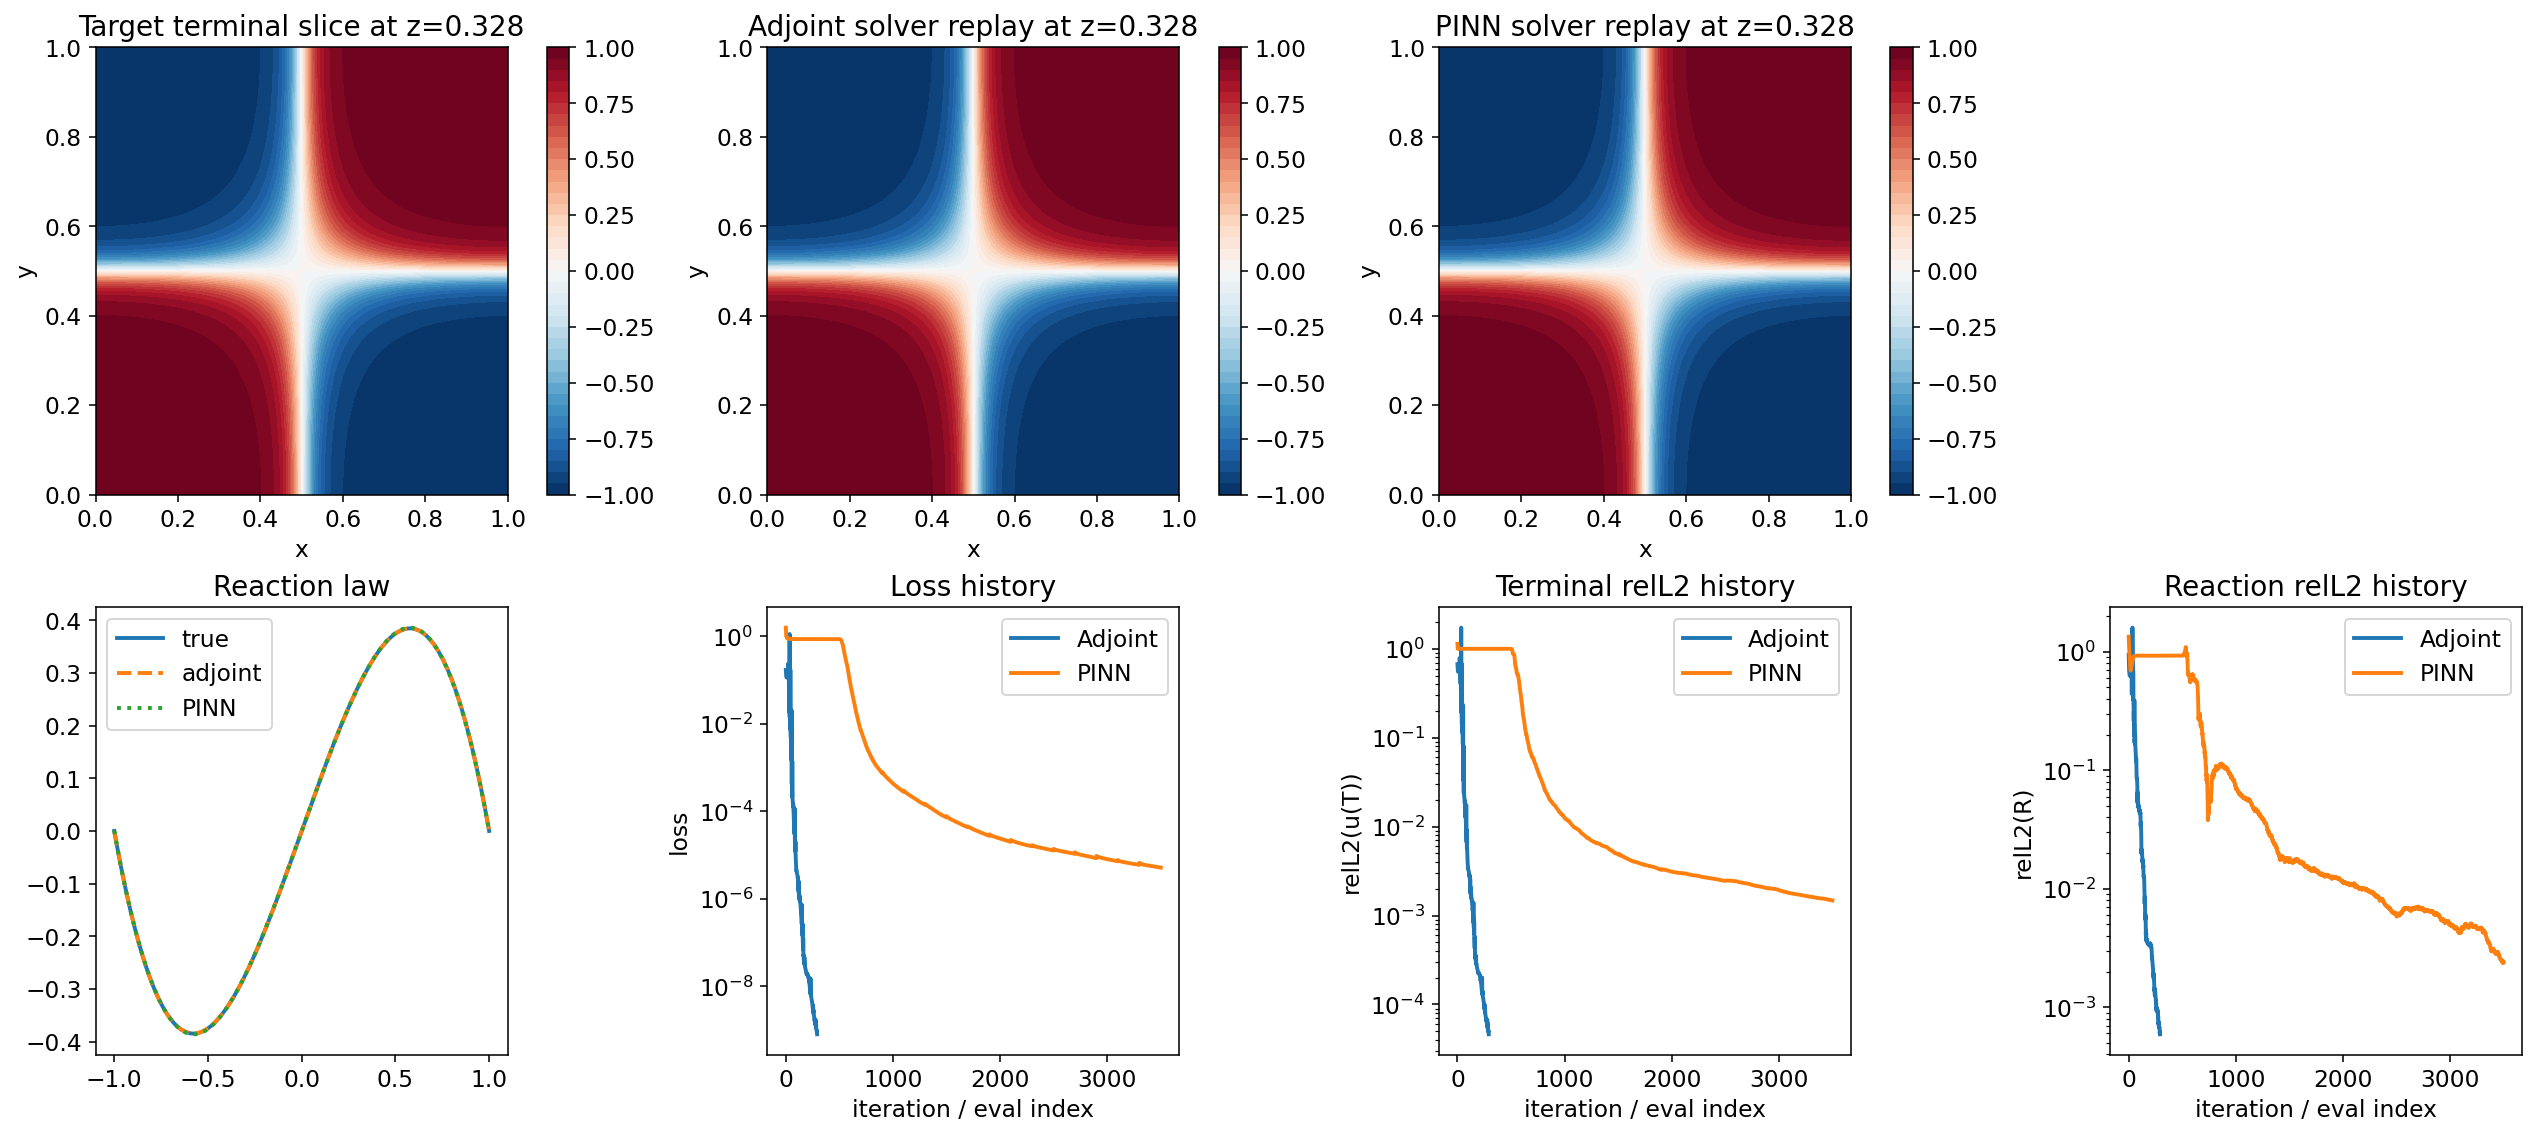

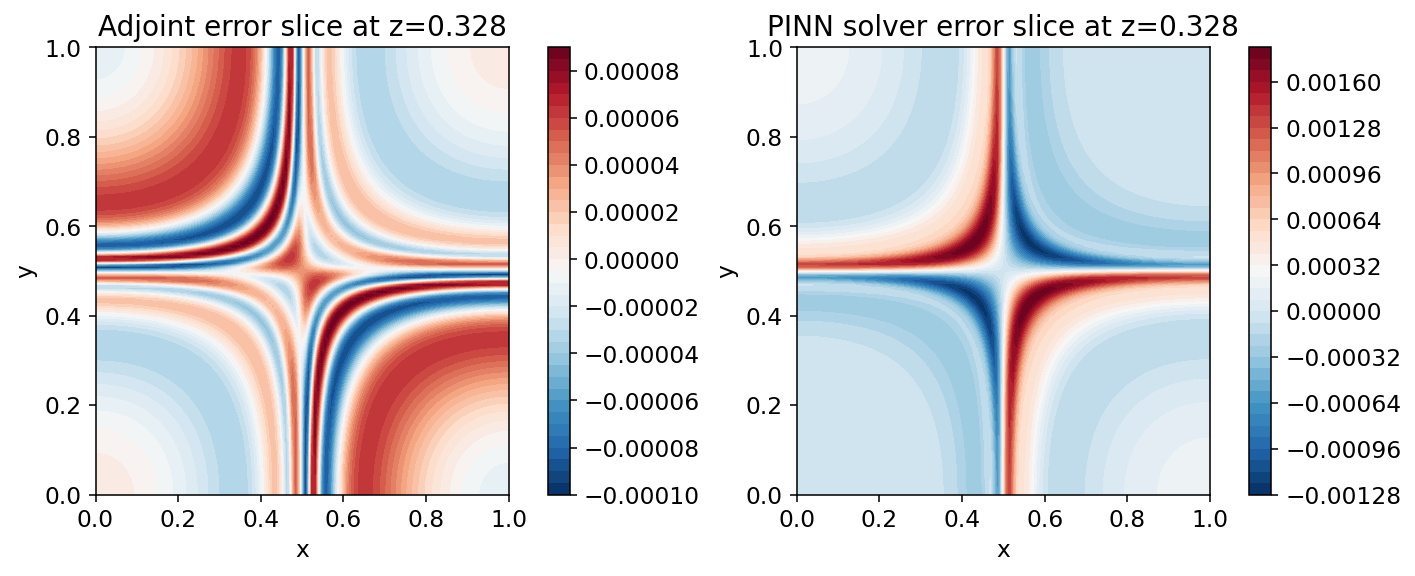

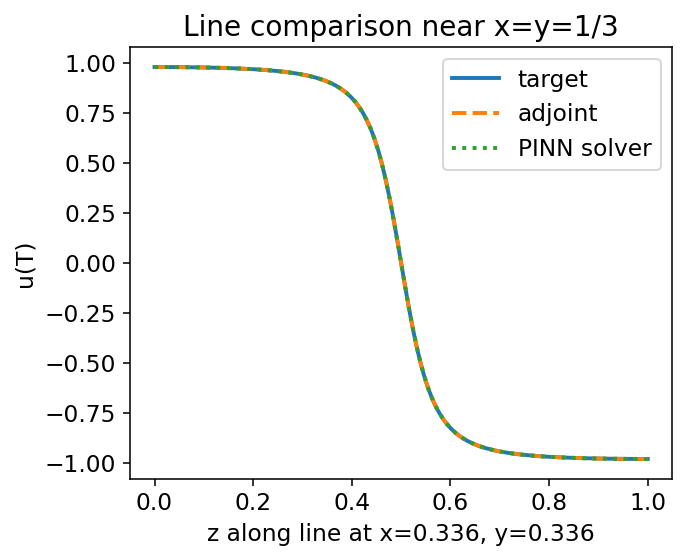

In [ ]:
u_probe = np.linspace(-1.0, 1.0, 1001)

if any(name not in globals() for name in ['cfg_inv', 'xx_inv', 'yy_inv', 'zz_inv', 'u0_inv', 'uT_target']):
    raise RuntimeError('Run the inverse setup cell before the comparison cell.')

if 'phi_adj' not in globals() or 'hist_adj' not in globals():
    if not os.path.exists(cfg_inv.adj_nn_path):
        raise FileNotFoundError(f'Missing adjoint history file: {cfg_inv.adj_nn_path}. Run the adjoint training cell first.')
    adj_blob = np.load(cfg_inv.adj_nn_path, allow_pickle=True)
    phi_adj = np.array(adj_blob['phi'], dtype=float)
    adj_evals = adj_blob['evals'].tolist()
    if isinstance(adj_evals, dict):
        adj_evals = [adj_evals]
    adj_iters = adj_blob['iters'].tolist() if 'iters' in adj_blob.files else []
    if isinstance(adj_iters, dict):
        adj_iters = [adj_iters]
    hist_adj = {
        'evals': adj_evals,
        'iters': adj_iters,
        'runtime_sec': float(np.array(adj_blob['runtime_sec']).reshape(())),
    }

if any(name not in globals() for name in ['hist_pinn', 'U_theta', 'S_phi']):
    if not os.path.exists(cfg_inv.pinn_scipy_path):
        raise FileNotFoundError(f'Missing PINN history file: {cfg_inv.pinn_scipy_path}. Run the PINN training cell first.')
    if not os.path.exists(cfg_inv.pinn_scipy_model):
        raise FileNotFoundError(f'Missing PINN model file: {cfg_inv.pinn_scipy_model}. Run the PINN training cell first.')

    pinn_blob = np.load(cfg_inv.pinn_scipy_path, allow_pickle=True)
    hist_pinn = {
        'adam': {
            'loss': np.array(pinn_blob['adam_loss'], dtype=float),
            'L_res': np.array(pinn_blob['adam_L_res'], dtype=float),
            'L_ic': np.array(pinn_blob['adam_L_ic'], dtype=float),
            'L_bc': np.array(pinn_blob['adam_L_bc'], dtype=float),
            'L_data': np.array(pinn_blob['adam_L_data'], dtype=float),
            'rel_l2_uT': np.array(pinn_blob['adam_rel_l2_uT'], dtype=float),
            'rel_l2_f': np.array(pinn_blob['adam_rel_l2_f'], dtype=float),
            'lr': np.array(pinn_blob['adam_lr'], dtype=float),
        },
        'bfgs': {
            'loss': np.array(pinn_blob['bfgs_loss'], dtype=float),
            'grad_norm': np.array(pinn_blob['bfgs_grad_norm'], dtype=float),
            'L_res': np.array(pinn_blob['bfgs_L_res'], dtype=float),
            'L_ic': np.array(pinn_blob['bfgs_L_ic'], dtype=float),
            'L_bc': np.array(pinn_blob['bfgs_L_bc'], dtype=float),
            'L_data': np.array(pinn_blob['bfgs_L_data'], dtype=float),
            'rel_l2_uT': np.array(pinn_blob['bfgs_rel_l2_uT'], dtype=float),
            'rel_l2_f': np.array(pinn_blob['bfgs_rel_l2_f'], dtype=float),
        },
        'runtime_sec': float(np.array(pinn_blob['runtime_sec']).reshape(())),
    }
    U_theta, S_phi = build_models(cfg_inv)
    load_models(cfg_inv, U_theta, S_phi, cfg_inv.pinn_scipy_model)

if 'uT_adj' not in globals():
    u_hist_adj, t_hist_adj = simulate_trajectory_with_phi(cfg_inv, u0_inv, phi_adj)
    uT_adj = u_hist_adj[-1]

if 'uT_pinn_direct' not in globals() or 'uT_pinn_solver' not in globals():
    with torch.no_grad():
        xyzt_T = torch.tensor(
            np.column_stack([
                xx_inv.reshape(-1),
                yy_inv.reshape(-1),
                zz_inv.reshape(-1),
                np.full(xx_inv.size, cfg_inv.t_final),
            ]),
            dtype=torch.float64,
            device=cfg_inv.device,
        )
        uT_pinn_direct = U_theta(xyzt_T).detach().cpu().numpy().reshape(cfg_inv.Nx, cfg_inv.Ny, cfg_inv.Nz)

    u_hist_pinn_solver, t_hist_pinn_solver, _ = solve_allen_cahn_imex(
        cfg_inv,
        u0_inv,
        reaction_fun=lambda u: reaction_from_model(S_phi, u, cfg_inv.device),
    )
    uT_pinn_solver = u_hist_pinn_solver[-1]

f_adj, _, _ = nn_force_forward(u_probe, phi_adj, cfg_inv)
f_true = reaction_true(u_probe)
f_pinn = reaction_from_model(S_phi, u_probe, cfg_inv.device)

adj_param_count = phi_adj.size
pinn_param_count = sum(p.numel() for p in U_theta.parameters()) + sum(p.numel() for p in S_phi.parameters())

def dense_hessian_gb(n_params):
    return 8.0 * n_params * n_params / 1.0e9

adj_loss_hist = np.array([row['loss'] for row in hist_adj['evals']], dtype=float)
adj_rel_uT_hist = np.array([row['rel_l2_uT'] for row in hist_adj['evals']], dtype=float)
adj_rel_f_hist = np.array([row['rel_l2_f'] for row in hist_adj['evals']], dtype=float)
adj_eval_axis = np.arange(len(adj_loss_hist))
adj_iter_rows = [row for row in hist_adj.get('iters', []) if row.get('phase') == 'bfgs']
adj_bfgs_loss_hist = np.array([row['loss'] for row in adj_iter_rows], dtype=float)
adj_bfgs_rel_f_hist = np.array([row['rel_l2_f'] for row in adj_iter_rows], dtype=float)
adj_bfgs_iter_axis = np.arange(1, len(adj_bfgs_loss_hist) + 1)

pinn_loss_hist = np.concatenate([hist_pinn['adam']['loss'], hist_pinn['bfgs']['loss']])
pinn_rel_uT_hist = np.concatenate([hist_pinn['adam']['rel_l2_uT'], hist_pinn['bfgs']['rel_l2_uT']])
pinn_rel_f_hist = np.concatenate([hist_pinn['adam']['rel_l2_f'], hist_pinn['bfgs']['rel_l2_f']])
pinn_iter_axis = np.arange(len(pinn_loss_hist))
pinn_bfgs = hist_pinn['bfgs']
pinn_bfgs_iter_axis = np.arange(1, len(pinn_bfgs['loss']) + 1)

print('Summary metrics')
print('---------------')
print(f'Adjoint terminal relL2 : {rel_l2_error(uT_adj, uT_target):.3e}')
print(f'PINN direct relL2     : {rel_l2_error(uT_pinn_direct, uT_target):.3e}')
print(f'PINN solver relL2     : {rel_l2_error(uT_pinn_solver, uT_target):.3e}')
print(f'Adjoint runtime [s]   : {hist_adj["runtime_sec"]:.3f}')
print(f'PINN runtime [s]      : {hist_pinn["runtime_sec"]:.3f}')
print(f'Adjoint params        : {adj_param_count}')
print(f'PINN params           : {pinn_param_count}')
print(f'Adjoint Hessian proxy : {dense_hessian_gb(adj_param_count):.3f} GB')
print(f'PINN Hessian proxy    : {dense_hessian_gb(pinn_param_count):.3f} GB')

z_target = 0.33
zslice_idx = int(np.argmin(np.abs(zz_inv[0, 0, :] - z_target)))
zslice_val = float(zz_inv[0, 0, zslice_idx])
x_target = 1.0 / 3.0
y_target = 1.0 / 3.0
xline_idx = int(np.argmin(np.abs(xx_inv[:, 0, 0] - x_target)))
yline_idx = int(np.argmin(np.abs(yy_inv[0, :, 0] - y_target)))
xline_val = float(xx_inv[xline_idx, 0, 0])
yline_val = float(yy_inv[0, yline_idx, 0])

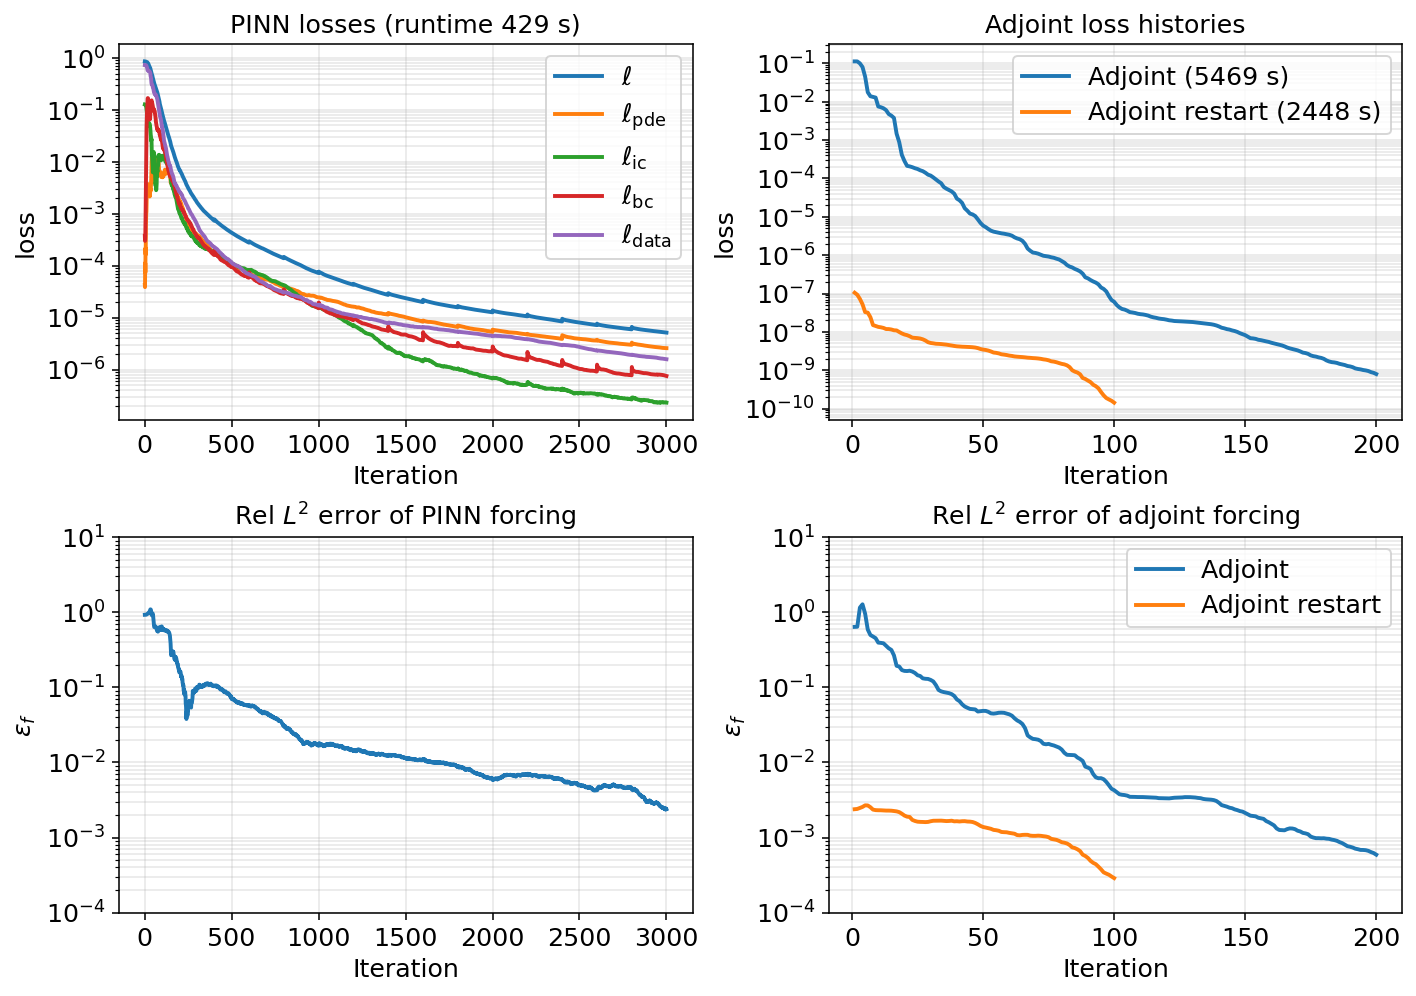

In [13]:
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import numpy as np
import os

adj_restart_path = globals().get('adj_restart_path', 'history/ac3d_adj_nn_restart.npz')
hist_adj_restart_plot = globals().get('hist_adj_restart', None)
if hist_adj_restart_plot is None and os.path.exists(adj_restart_path):
    adj_restart_blob = np.load(adj_restart_path, allow_pickle=True)
    adj_restart_evals = adj_restart_blob['evals'].tolist()
    if isinstance(adj_restart_evals, dict):
        adj_restart_evals = [adj_restart_evals]
    adj_restart_iters = adj_restart_blob['iters'].tolist() if 'iters' in adj_restart_blob.files else []
    if isinstance(adj_restart_iters, dict):
        adj_restart_iters = [adj_restart_iters]
    hist_adj_restart_plot = {
        'evals': adj_restart_evals,
        'iters': adj_restart_iters,
        'runtime_sec': float(np.array(adj_restart_blob['runtime_sec']).reshape(())),
    }

adj_restart_iter_rows = []
adj_restart_bfgs_loss_hist = np.array([])
adj_restart_bfgs_rel_f_hist = np.array([])
adj_restart_bfgs_iter_axis = np.array([])
if hist_adj_restart_plot is not None:
    adj_restart_iter_rows = [row for row in hist_adj_restart_plot.get('iters', []) if row.get('phase') == 'bfgs']
    adj_restart_bfgs_loss_hist = np.array([row['loss'] for row in adj_restart_iter_rows], dtype=float)
    adj_restart_bfgs_rel_f_hist = np.array([row['rel_l2_f'] for row in adj_restart_iter_rows], dtype=float)
    adj_restart_bfgs_iter_axis = np.arange(1, len(adj_restart_bfgs_loss_hist) + 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
axes = axes.ravel()
axes[0].semilogy(pinn_bfgs_iter_axis, pinn_bfgs['loss'] + 1.0e-30, lw=2, label=r'$\ell$')
axes[0].semilogy(pinn_bfgs_iter_axis, pinn_bfgs['L_res'] + 1.0e-30, lw=2, label=r'$\ell_{\text{pde}}$')
axes[0].semilogy(pinn_bfgs_iter_axis, pinn_bfgs['L_ic'] + 1.0e-30, lw=2, label=r'$\ell_{\text{ic}}$')
axes[0].semilogy(pinn_bfgs_iter_axis, pinn_bfgs['L_bc'] + 1.0e-30, lw=2, label=r'$\ell_{\text{bc}}$')
axes[0].semilogy(pinn_bfgs_iter_axis, pinn_bfgs['L_data'] + 1.0e-30, lw=2, label=r'$\ell_{\text{data}}$')
axes[0].set_title(f'PINN losses (runtime {hist_pinn["runtime_sec"]:.0f} s)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('loss')
axes[0].legend()

axes[1].semilogy(adj_bfgs_iter_axis, adj_bfgs_loss_hist + 1.0e-30, lw=2, color='C0', label=f'Adjoint ({hist_adj["runtime_sec"]:.0f} s)')
if adj_restart_bfgs_loss_hist.size > 0:
    axes[1].semilogy(adj_restart_bfgs_iter_axis, adj_restart_bfgs_loss_hist + 1.0e-30, lw=2, color='C1', label=f'Adjoint restart ({hist_adj_restart_plot["runtime_sec"]:.0f} s)')
axes[1].set_title('Adjoint loss histories')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('loss')
# Force one major tick per order of magnitude on panel 2.
axes[1].set_yscale('log')
axes[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=100))
axes[1].yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
axes[1].legend()

axes[2].semilogy(pinn_bfgs_iter_axis, pinn_bfgs['rel_l2_f'] + 1.0e-30, lw=2)
axes[2].set_title(r'Rel $L^2$ error of PINN forcing')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel(r'$\varepsilon_f$')

axes[3].semilogy(adj_bfgs_iter_axis, adj_bfgs_rel_f_hist + 1.0e-30, lw=2, color='C0', label='Adjoint ')
if adj_restart_bfgs_rel_f_hist.size > 0:
    axes[3].semilogy(adj_restart_bfgs_iter_axis, adj_restart_bfgs_rel_f_hist + 1.0e-30, lw=2, color='C1', label='Adjoint restart')
axes[3].set_title(r'Rel $L^2$ error of adjoint forcing')
axes[3].set_xlabel('Iteration')
axes[3].set_ylabel(r'$\varepsilon_f$')
axes[3].legend()

force_histories = [np.asarray(pinn_bfgs['rel_l2_f'], dtype=float), np.asarray(adj_bfgs_rel_f_hist, dtype=float)]
if adj_restart_bfgs_rel_f_hist.size > 0:
    force_histories.append(np.asarray(adj_restart_bfgs_rel_f_hist, dtype=float))
force_positive = np.concatenate([hist[hist > 0.0] for hist in force_histories if hist.size > 0])
if force_positive.size > 0:
    force_ymin = 10.0 ** np.floor(np.log10(force_positive.min()))
    force_ymax = 10.0 ** np.ceil(np.log10(force_positive.max()))
    axes[2].set_ylim(force_ymin, force_ymax)
    axes[3].set_ylim(force_ymin, force_ymax)

for idx, ax in enumerate(axes):
    ax.grid(True, which='both', alpha=0.3)
    ax.set_title(ax.get_title(), fontsize=13)
    ax.set_xlabel(ax.get_xlabel(), fontsize=13)
    ax.set_ylabel(ax.get_ylabel(), fontsize=13)
    ax.tick_params(axis='both', which='both', labelsize=13)

for legend_ax in (axes[0], axes[1], axes[3]):
    legend = legend_ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(13)

os.makedirs('figures', exist_ok=True)
fig.savefig('figures/training_history.png', bbox_inches='tight', dpi=300)
plt.show()

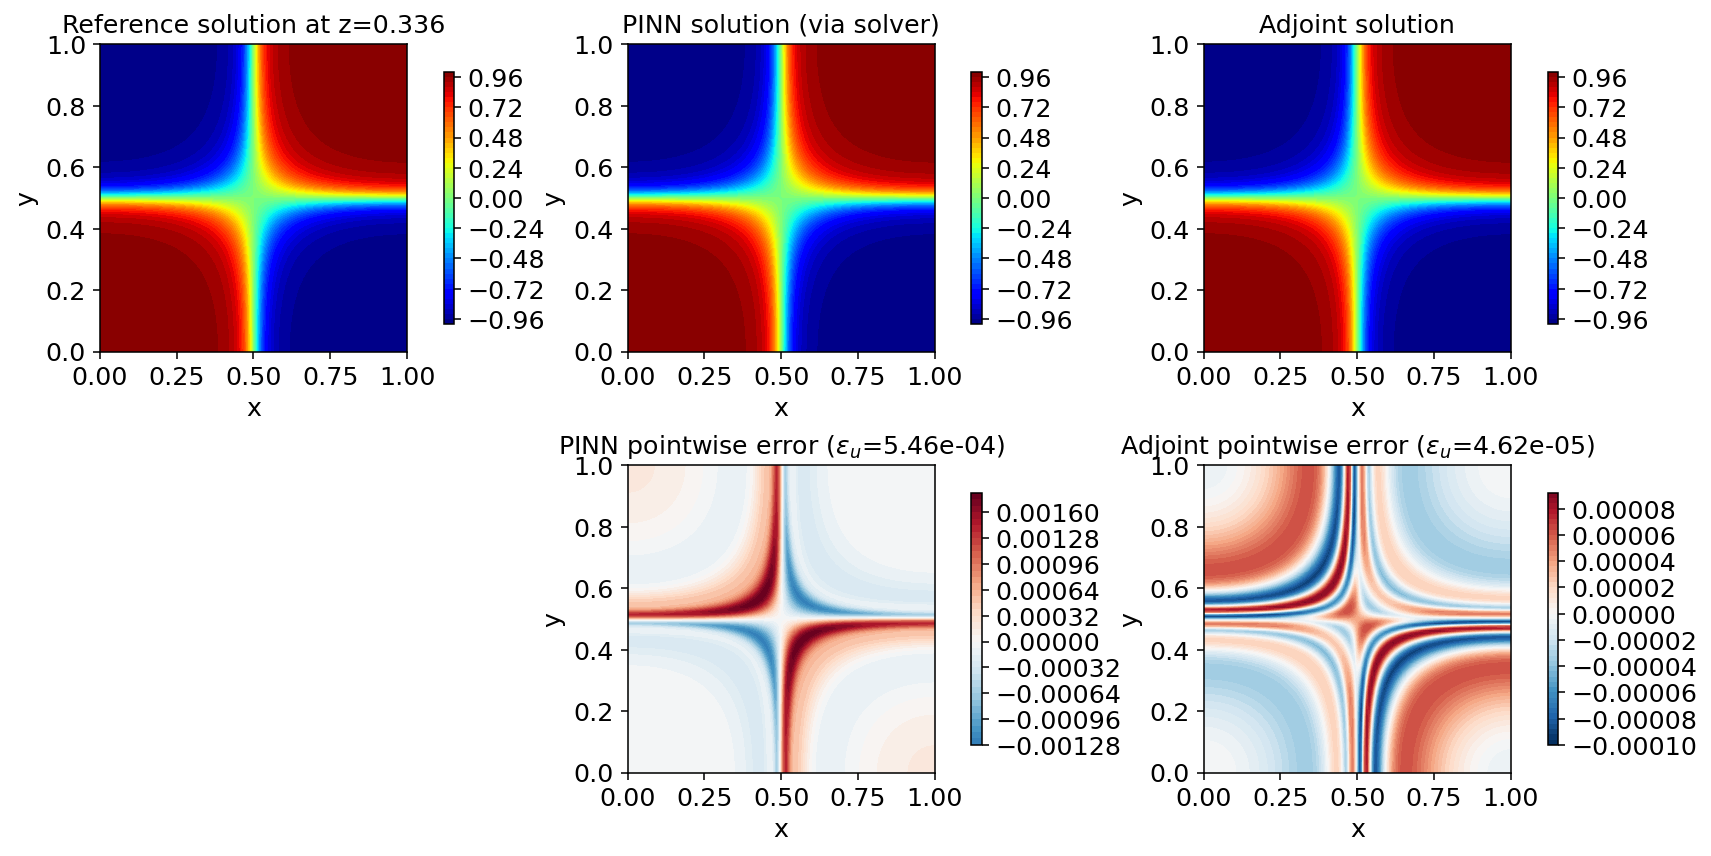

In [8]:
from matplotlib.colors import TwoSlopeNorm

required_vars = ['xx_inv', 'yy_inv', 'zz_inv', 'uT_target', 'uT_pinn_solver', 'uT_adj']
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(f'Missing variables: {missing}. Run the comparison/training cells first.')

z_target = 1.0 / 3.0
z_idx = int(np.argmin(np.abs(zz_inv[0, 0, :] - z_target)))
z_val = float(zz_inv[0, 0, z_idx])

x_plane = xx_inv[:, :, z_idx]
y_plane = yy_inv[:, :, z_idx]

u_ref_xy = uT_target[:, :, z_idx]
u_pinn_xy = uT_pinn_solver[:, :, z_idx]
u_adj_xy = uT_adj[:, :, z_idx]

err_pinn_xy = u_pinn_xy - u_ref_xy
err_adj_xy = u_adj_xy - u_ref_xy

# Relative L2 errors over the full 3D terminal state.
rel_l2_pinn_full = rel_l2_error(uT_pinn_solver, uT_target)
rel_l2_adj_full = rel_l2_error(uT_adj, uT_target)

# Shared normalization for the first three solution panels.
sol_min = min(float(np.min(u_ref_xy)), float(np.min(u_pinn_xy)), float(np.min(u_adj_xy)))
sol_max = max(float(np.max(u_ref_xy)), float(np.max(u_pinn_xy)), float(np.max(u_adj_xy)))
if sol_min < 0.0 < sol_max:
    sol_norm = TwoSlopeNorm(vmin=sol_min, vcenter=0.0, vmax=sol_max)
else:
    sol_norm = None

# Independent normalization for each error panel.
err_abs_max_pinn = max(float(np.max(np.abs(err_pinn_xy))), 1.0e-15)
err_abs_max_adj = max(float(np.max(np.abs(err_adj_xy))), 1.0e-15)
err_norm_pinn = TwoSlopeNorm(vmin=-err_abs_max_pinn, vcenter=0.0, vmax=err_abs_max_pinn)
err_norm_adj = TwoSlopeNorm(vmin=-err_abs_max_adj, vcenter=0.0, vmax=err_abs_max_adj)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
# Smaller colorbars for all plotted panels.
cb_kwargs = dict(fraction=0.042, pad=0.025, shrink=0.82, aspect=24)

# Panels 1-3 use jet and each has its own colorbar (same shared scale).
im_ref = axes[0, 0].contourf(x_plane, y_plane, u_ref_xy, levels=50, cmap='jet', norm=sol_norm)
axes[0, 0].set_title(f'Reference solution at z={z_val:.3f}', fontsize=13)
axes[0, 0].set_xlabel('x', fontsize=13)
axes[0, 0].set_ylabel('y', fontsize=13)
cb_ref = fig.colorbar(im_ref, ax=axes[0, 0], **cb_kwargs)
cb_ref.ax.tick_params(labelsize=13)

im_pinn = axes[0, 1].contourf(x_plane, y_plane, u_pinn_xy, levels=50, cmap='jet', norm=sol_norm)
axes[0, 1].set_title('PINN solution (via solver)', fontsize=13)
axes[0, 1].set_xlabel('x', fontsize=13)
axes[0, 1].set_ylabel('y', fontsize=13)
cb_pinn = fig.colorbar(im_pinn, ax=axes[0, 1], **cb_kwargs)
cb_pinn.ax.tick_params(labelsize=13)

im_adj = axes[0, 2].contourf(x_plane, y_plane, u_adj_xy, levels=50, cmap='jet', norm=sol_norm)
axes[0, 2].set_title('Adjoint solution', fontsize=13)
axes[0, 2].set_xlabel('x', fontsize=13)
axes[0, 2].set_ylabel('y', fontsize=13)
cb_adj = fig.colorbar(im_adj, ax=axes[0, 2], **cb_kwargs)
cb_adj.ax.tick_params(labelsize=13)

# Panel 4 is empty.
axes[1, 0].axis('off')

# Panels 5-6 use red-blue and each has its own colorbar.
im_err_pinn = axes[1, 1].contourf(x_plane, y_plane, err_pinn_xy, levels=50, cmap='RdBu_r', norm=err_norm_pinn)
axes[1, 1].set_title(fr'PINN pointwise error ($\varepsilon_u$={rel_l2_pinn_full:.2e})', fontsize=13)
axes[1, 1].set_xlabel('x', fontsize=13)
axes[1, 1].set_ylabel('y', fontsize=13)
cb_err_pinn = fig.colorbar(im_err_pinn, ax=axes[1, 1], **cb_kwargs)
cb_err_pinn.ax.tick_params(labelsize=13)

im_err_adj = axes[1, 2].contourf(x_plane, y_plane, err_adj_xy, levels=50, cmap='RdBu_r', norm=err_norm_adj)
axes[1, 2].set_title(fr'Adjoint pointwise error ($\varepsilon_u$={rel_l2_adj_full:.2e})', fontsize=13)
axes[1, 2].set_xlabel('x', fontsize=13)
axes[1, 2].set_ylabel('y', fontsize=13)
cb_err_adj = fig.colorbar(im_err_adj, ax=axes[1, 2], **cb_kwargs)
cb_err_adj.ax.tick_params(labelsize=13)

for row in range(2):
    for col in range(3):
        axes[row, col].tick_params(axis='both', which='both', labelsize=13)
        if not (row == 1 and col == 0):
            axes[row, col].set_aspect('equal')

os.makedirs('figures', exist_ok=True)
fig.savefig('figures/terminal_solution_slice.png', bbox_inches='tight', dpi=300)
plt.show()

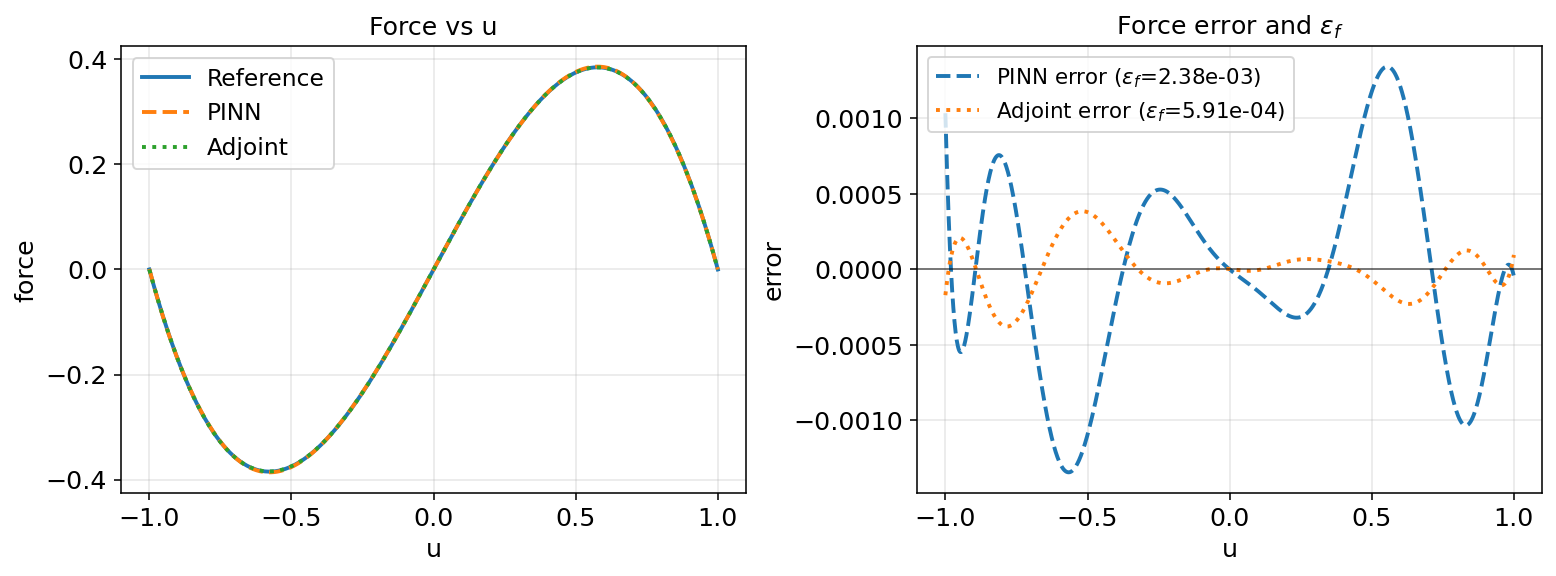

In [9]:
u_force = np.linspace(-1.0, 1.0, 1001)
f_ref_force = reaction_true(u_force)

if 'cfg_inv' in globals() and 'S_phi' in globals():
    f_pinn_force = reaction_from_model(S_phi, u_force, cfg_inv.device)
elif 'f_pinn' in globals():
    f_pinn_force = np.asarray(f_pinn, dtype=float).reshape(-1)
    if f_pinn_force.size != u_force.size:
        raise RuntimeError('PINN force data has incompatible size.')
else:
    raise RuntimeError('Missing PINN force model/data. Run the PINN training/comparison cells first.')

if 'cfg_inv' in globals() and 'phi_adj' in globals():
    f_adj_force, _, _ = nn_force_forward(u_force, phi_adj, cfg_inv)
elif 'f_adj' in globals():
    f_adj_force = np.asarray(f_adj, dtype=float).reshape(-1)
    if f_adj_force.size != u_force.size:
        raise RuntimeError('Adjoint force data has incompatible size.')
else:
    raise RuntimeError('Missing adjoint force model/data. Run the adjoint/comparison cells first.')

eps_f_pinn = rel_l2_error(f_pinn_force, f_ref_force)
eps_f_adj = rel_l2_error(f_adj_force, f_ref_force)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(u_force, f_ref_force, lw=2, label='Reference')
axes[0].plot(u_force, f_pinn_force, '--', lw=2, label='PINN')
axes[0].plot(u_force, f_adj_force, ':', lw=2, label='Adjoint')
axes[0].set_title('Force vs u', fontsize=13)
axes[0].set_xlabel('u', fontsize=13)
axes[0].set_ylabel('force', fontsize=13)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(u_force, f_pinn_force - f_ref_force, '--', lw=2, label=fr'PINN error ($\varepsilon_f$={eps_f_pinn:.2e})')
axes[1].plot(u_force, f_adj_force - f_ref_force, ':', lw=2, label=fr'Adjoint error ($\varepsilon_f$={eps_f_adj:.2e})')
axes[1].axhline(0.0, color='k', lw=1, alpha=0.5)
axes[1].set_title(r'Force error and $\varepsilon_f$', fontsize=13)
axes[1].set_xlabel('u', fontsize=13)
axes[1].set_ylabel('error', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='both', which='both', labelsize=13)

os.makedirs('figures', exist_ok=True)
fig.savefig('figures/force_recovery.png', bbox_inches='tight', dpi=300)
plt.show()